## Code for plotting Site U1602 XRF data 
note: instead of one continuous hole drilled down to the base of the site, we combined (concatenate) data from Holes U1602D and E. This is because Hole E begins where Hole D stopped, and together, they form the longest "continous" portion of Site U1602. They were also combined for the elemental cross plots and correlations to be consistent with correlations through the longest hole

In [1]:
import pandas, numpy, scipy, matplotlib, seaborn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import scipy.signal as signal
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches

In [38]:
###  Import Site U1602 Eirik Drift XRF data ###
# Splice 
splice_10kV = pd.read_csv('data/U1602/splice/SPLICE-395-U1602-BCD-20230729_10kV_0_30mA_No-Filter_10s_DC10mm_CC12mm_Clean.csv')
splice_30kV = pd.read_csv('data/U1602/splice/SPLICE-395-U1602-BCD-20230729_30kV_1_50mA_Pd-Thick_10s_DC10mm_CC12mm_Clean.csv')
splice_50kV = pd.read_csv('data/U1602/splice/SPLICE-395-U1602-BCD-20230729_50kV_2_00mA_Cu_20s_DC10mm_CC12mm_Clean.csv')

# Hole E and D 
E_10kV = pd.read_csv('data/U1602/hole_D_E/395_U1602E_10kV_0_30mA_No-Filter_10s_DC10mm_CC12mm_Clean.csv')
E_30kV = pd.read_csv('data/U1602/hole_D_E/395_U1602E_30kV_1_50mA_Pd-Thick_10s_DC10mm_CC12mm_Clean.csv')
E_50kV = pd.read_csv('data/U1602/hole_D_E/395_U1602E_50kV_2_00mA_Cu_20s_DC10mm_CC12mm_Clean.csv')

D_10kV = pd.read_csv('data/U1602/hole_D_E/395_U1602D_10kV_0_30mA_No-Filter_10s_DC10mm_CC12mm_Clean.csv')
D_30kV = pd.read_csv('data/U1602/hole_D_E/395_U1602D_30kV_1_50mA_Pd-Thick_10s_DC10mm_CC12mm_Clean.csv')
D_50kV = pd.read_csv('data/U1602/hole_D_E/395_U1602D_50kV_2_00mA_Cu_20s_DC10mm_CC12mm_Clean.csv')

# Hole E and D phys props
U1602E_ms = pd.read_csv('data/U1602/phys_props/U1602_MS_E.csv')
U1602E_ngr = pd.read_csv('data/U1602/phys_props/U1602_NGR_E.csv')

U1602D_ms = pd.read_csv('data/U1602/phys_props/U1602_MS_D.csv')
U1602D_ngr = pd.read_csv('data/U1602/phys_props/U1602_NGR_D.csv')

# splice phys props 
U1602splice_ms = pd.read_csv('data/U1602/phys_props/U1602_MS_splice.csv')
U1602splice_ngr = pd.read_csv('data/U1602/phys_props/U1602_NGR_splice.csv')

# age model and lith units 

U1602agemodel = pd.read_csv('data/U1602/age_model/U1602_AgeModel_CSF_CCSF.csv')
U1602lithunits=pd.read_csv('data/U1602/age_model/U1602_litho_Units.csv')


In [3]:
GSA_EPOCH_COLORS = {
    'Pleistocene': '#FEEFBC',
    'Pliocene':    '#FFF8AE',
    'Miocene':     '#FFF101',
    'Oligocene':   '#FEDAAB',
    'Eocene':      '#FBBB85',
}

<Figure size 1800x1200 with 0 Axes>

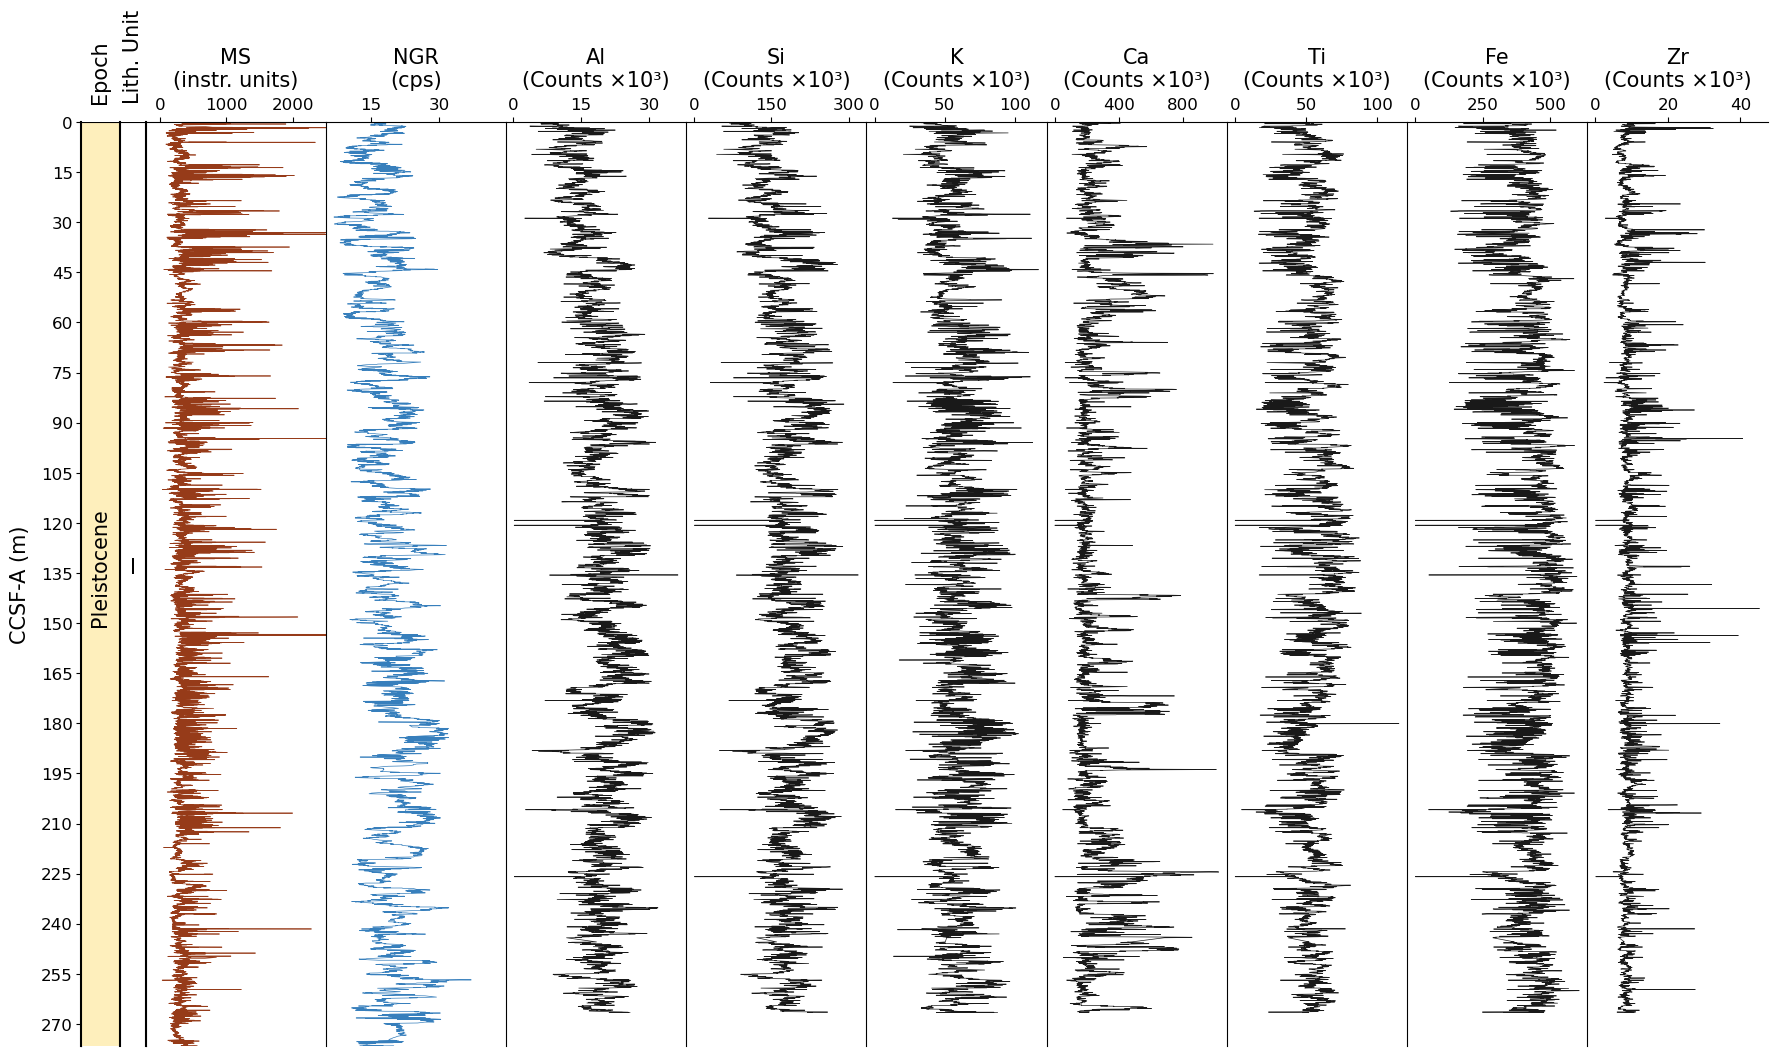

In [41]:
depth = 'CCSF-395-U1602-BCD-20230729 (m)'

colors = {
    'Al': 'black', 'Si': 'black', 'K':  'black', 'Ca': 'black',
    'Ti': 'black', 'Fe': 'black', 'Zr': 'black',
}
elements = {
    'Al': (splice_10kV, 'Al-Ka Area'),
    'Si': (splice_10kV, 'Si-Ka Area'),
    'K':  (splice_10kV, 'K-Ka Area'),
    'Ca': (splice_10kV, 'Ca-Ka Area'),
    'Ti': (splice_10kV, 'Ti-Ka Area'),
    'Fe': (splice_10kV, 'Fe-Ka Area'),
    'Zr': (splice_30kV, 'Zr-Ka Area'),
}

# ── boundaries using CCSF-A depths ───────────────────────────────────────────
lith_boundaries  = [0.0] + list(U1602lithunits['Depth CCSF-A (m)'])
lith_labels      = ['']  + list(U1602lithunits['Lith Unit'])

epoch_boundaries = [0.0] + list(U1602agemodel['Depth CCSF-A (m)'])
epoch_labels     = ['']  + list(U1602agemodel['Event (base)'])

boundaries = list(U1602lithunits['Depth CCSF-A (m)'])  # dashed lines on data panels

y_min = 0
y_max = max(splice_10kV[depth].max(), splice_30kV[depth].max())

n_cols = 1 + 1 + 1 + len(elements)   # depth | epoch | lith | elements

fig = plt.figure(figsize=(4 + 2*len(elements), 12))
gs  = gridspec.GridSpec(1, n_cols,
                        width_ratios=[0.10, 0.22, 0.14] + [1]*len(elements),
                        wspace=0.0)


# ── reusable boundary drawing function ───────────────────────────────────────
def draw_boundaries(ax, depths, labels, fontsize=9, rotation=0,
                    left_line=True, right_line=True, epoch_colors=None,
                    y_max=None):
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.tick_params(axis='y', left=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    trans_data = blended_transform_factory(ax.transAxes, ax.transData)
    trans_axes = ax.transAxes

    if epoch_colors:
        for i in range(1, len(depths)):
            color = epoch_colors.get(labels[i], 'white')
            ax.axhspan(depths[i-1], depths[i], facecolor=color, alpha=1.0, zorder=1)

    for d in depths:
        ax.axhline(d, color='black', linewidth=0.8, zorder=3)

    if left_line:
        ax.plot([0, 0], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)
    if right_line:
        ax.plot([1, 1], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)

    for i in range(1, len(depths)):
        top    = depths[i-1]
        bottom = depths[i]
        # cap bottom at y_max so the label stays visible for the last interval
        if y_max is not None:
            bottom = min(bottom, y_max)
        mid = (top + bottom) / 2
        ax.text(0.5, mid, labels[i],
                ha='center', va='center',
                fontsize=fontsize, fontweight='400', color='black',
                rotation=rotation,
                transform=trans_data, zorder=4, clip_on=True)

# ── MS and NGR panels (first after depth/epoch/lith) ─────────────────────────
extra_panels = [
    {
        'df':    U1602splice_ms,
        'xcol':  'Magnetic susceptibility (instr. units)',
        'ycol':  'Depth CCSF-395-U1602-BCD-20230729 (m)',
        'label': 'MS\n(instr. units)',
        'color': '#8B2500',
        'xlim':  (None, 2500),
    },
    {
        'df':    U1602splice_ngr,
        'xcol':  'NGR total counts (cps)',
        'ycol':  'Depth CCSF-395-U1602-BCD-20230729 (m)',
        'label': 'NGR\n(cps)',
        'color': '#2171B5',
        'xlim':  (None, None),
    },
]

n_extra = len(extra_panels)
n_xrf   = len(elements)
n_cols  = 1 + 1 + 1 + n_extra + n_xrf   # depth | epoch | lith | MS | NGR | XRF...

fig = plt.figure(figsize=(4 + 2*(n_extra + n_xrf), 12))
gs  = gridspec.GridSpec(1, n_cols,
                        width_ratios=[0.10, 0.22, 0.14] + [1]*(n_extra + n_xrf),
                        wspace=0.0)

# ── depth axis ────────────────────────────────────────────────────────────────
ax_depth = fig.add_subplot(gs[0])
ax_depth.set_ylim(y_max+10, y_min)
ax_depth.set_xlim(0, 1)
ax_depth.set_xticks([])
ax_depth.yaxis.set_major_locator(plt.MaxNLocator(25))
ax_depth.tick_params(axis='y', labelsize=12, left=True, labelleft=True,
                     right=False, pad=2)
ax_depth.set_ylabel('CCSF-A (m)', fontsize=15, labelpad=8)
for spine in ax_depth.spines.values():
    spine.set_visible(False)
ax_depth.spines['left'].set_visible(True)

# ── epoch axis ────────────────────────────────────────────────────────────────
ax_age = fig.add_subplot(gs[1], sharey=ax_depth)
draw_boundaries(ax_age, epoch_boundaries, epoch_labels,
                fontsize=15, rotation=90,
                left_line=True, right_line=False,
                epoch_colors=GSA_EPOCH_COLORS, y_max=y_max)
ax_age.text(0.5, 1.02, 'Epoch', fontsize=15,
            ha='center', va='bottom', rotation=90,
            transform=ax_age.transAxes)

# ── lith axis ─────────────────────────────────────────────────────────────────
ax_lith = fig.add_subplot(gs[2], sharey=ax_depth)
draw_boundaries(ax_lith, lith_boundaries, lith_labels,
                fontsize=15, rotation=0,
                left_line=True, right_line=True, y_max=y_max)
ax_lith.text(0.5, 1.02, 'Lith. Unit', fontsize=15,
             ha='center', va='bottom', rotation=90,
             transform=ax_lith.transAxes)

# ── MS and NGR panels ─────────────────────────────────────────────────────────
extra_axes = [fig.add_subplot(gs[i+3], sharey=ax_depth) for i in range(n_extra)]

for i, (ax, panel) in enumerate(zip(extra_axes, extra_panels)):
    # for b in boundaries:
    #     ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    df   = panel['df']
    xcol = panel['xcol']
    ycol = panel['ycol']

    ax.plot(df[xcol], df[ycol], color=panel['color'], linewidth=0.5, alpha=0.9)

    if panel['xlim'] != (None, None):
        ax.set_xlim(panel['xlim'])

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(panel['label'], fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['left'].set_visible(True)

# ── XRF element panels ────────────────────────────────────────────────────────
all_axes = [fig.add_subplot(gs[i+3+n_extra], sharey=ax_depth) for i in range(n_xrf)]

for i, (ax, (element, (df, col))) in enumerate(zip(all_axes, elements.items())):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ax.plot(df[col], df[depth], color=colors[element], linewidth=0.5, alpha=0.9)

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(f'{element}\n(Counts ×10³)', fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['left'].set_visible(True)

# ── flush to depth spine ──────────────────────────────────────────────────────
fig.canvas.draw()
spine_x   = ax_depth.spines['left'].get_window_extent().x1
lith_left = fig.transFigure.inverted().transform((spine_x, 0))[0]
shift     = ax_age.get_position().x0 - lith_left

for ax in [ax_age, ax_lith] + extra_axes + all_axes:
    pos = ax.get_position()
    ax.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

plt.show()

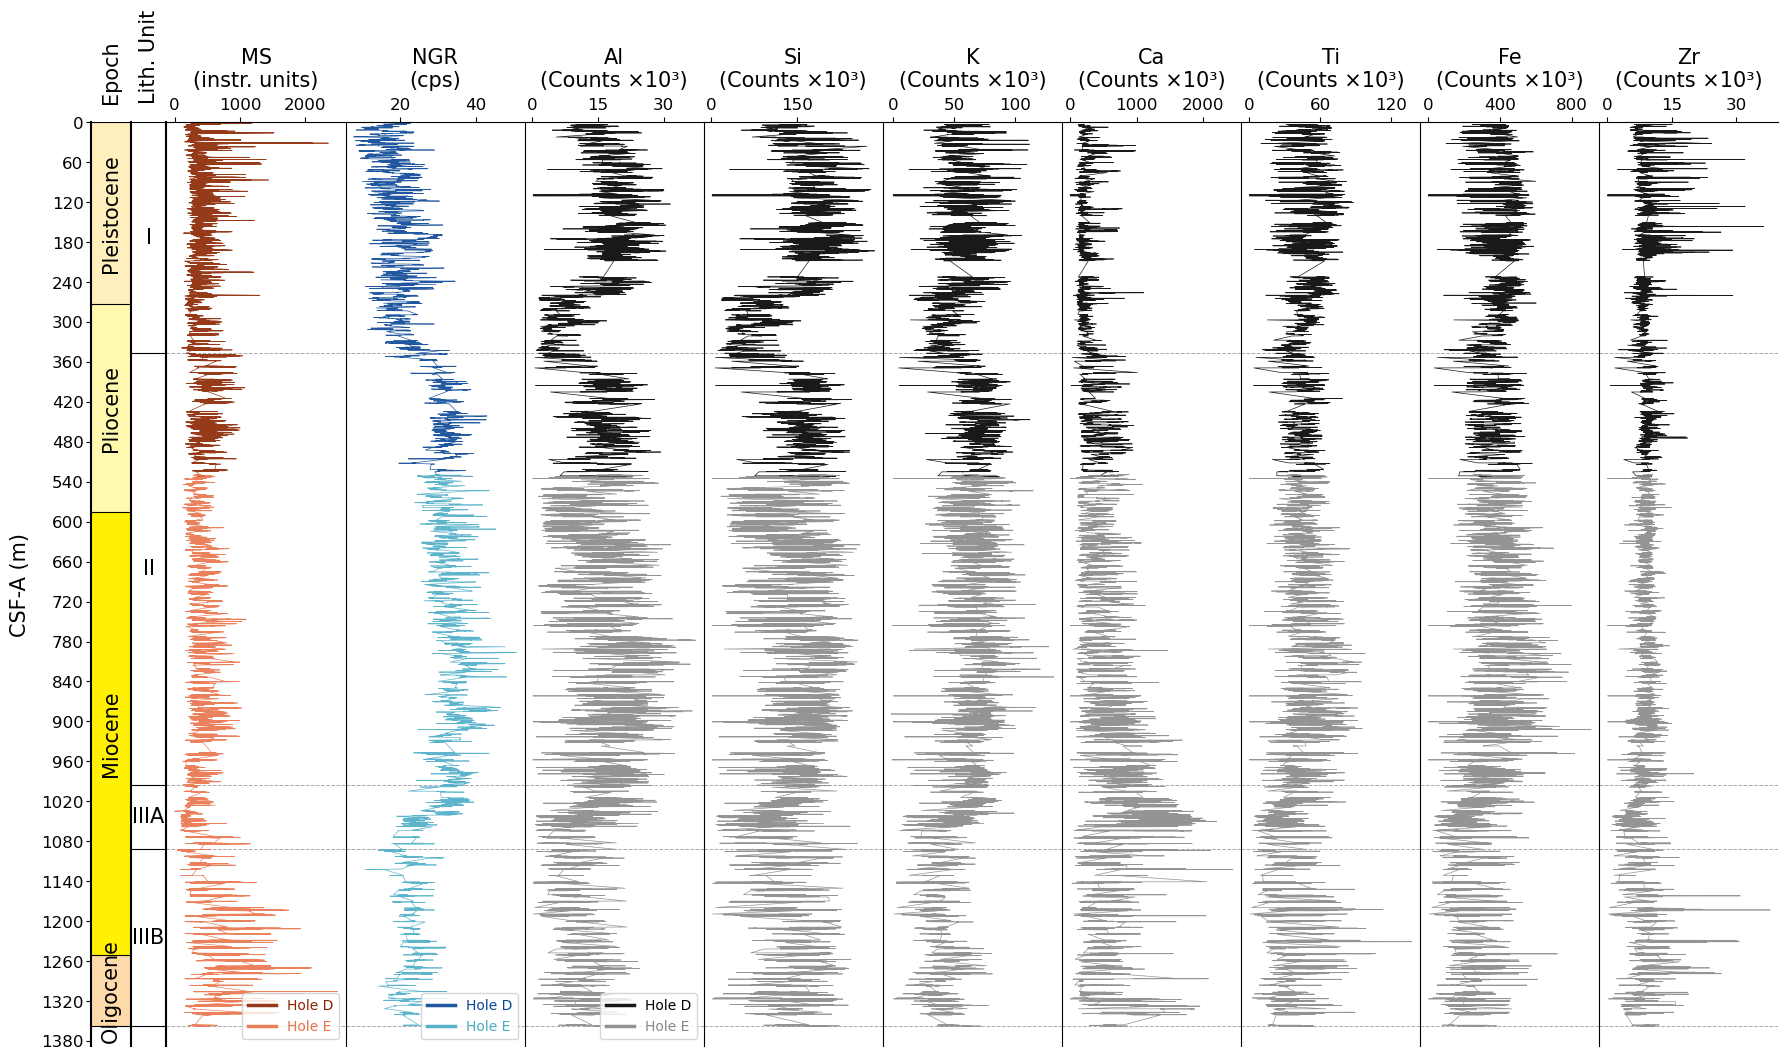

In [47]:
depth_DE = 'CSF-A (m)'

# ── colors ────────────────────────────────────────────────────────────────────
hole_colors = {
    'MS':  {'D': '#8B2500', 'E': '#E8724A'},
    'NGR': {'D': '#084594', 'E': '#4BACC6'},
    'XRF': {'D': 'black',   'E': '#888888'},
}

# ── boundaries using CSF-A depths ─────────────────────────────────────────────
lith_boundaries  = [0.0] + list(U1602lithunits['Depth CSF-A (m)'])
lith_labels      = ['']  + list(U1602lithunits['Lith Unit'])

epoch_boundaries = [0.0] + list(U1602agemodel['Depth CSF-A (m)'])
epoch_labels     = ['']  + list(U1602agemodel['Event (base)'])

boundaries = []

y_min_DE = 0
y_max_DE = max(D_10kV[depth_DE].max(), E_10kV[depth_DE].max(),
               D_30kV[depth_DE].max(), E_30kV[depth_DE].max())

# ── extra panels — keep D and E separate ─────────────────────────────────────
extra_panels = [
    {
        'label': 'MS\n(instr. units)',
        'D': {'df': U1602D_ms,  'xcol': 'Magnetic susceptibility (instr. units)', 'ycol': 'Depth CSF-A (m)'},
        'E': {'df': U1602E_ms,  'xcol': 'Magnetic susceptibility (instr. units)', 'ycol': 'Depth CSF-A (m)'},
        'xlim': (None, None),
        'color_key': 'MS',
    },
    {
        'label': 'NGR\n(cps)',
        'D': {'df': U1602D_ngr, 'xcol': 'NGR total counts (cps)', 'ycol': 'Depth CSF-A (m)'},
        'E': {'df': U1602E_ngr, 'xcol': 'NGR total counts (cps)', 'ycol': 'Depth CSF-A (m)'},
        'xlim': (None, None),
        'color_key': 'NGR',
    },
]

# ── element definitions — keep D and E separate ───────────────────────────────
elements_DE = {
    'Al': {'D': (D_10kV, 'Al-Ka Area'), 'E': (E_10kV, 'Al-Ka Area')},
    'Si': {'D': (D_10kV, 'Si-Ka Area'), 'E': (E_10kV, 'Si-Ka Area')},
    'K':  {'D': (D_10kV, 'K-Ka Area'),  'E': (E_10kV, 'K-Ka Area')},
    'Ca': {'D': (D_10kV, 'Ca-Ka Area'), 'E': (E_10kV, 'Ca-Ka Area')},
    'Ti': {'D': (D_10kV, 'Ti-Ka Area'), 'E': (E_10kV, 'Ti-Ka Area')},
    'Fe': {'D': (D_10kV, 'Fe-Ka Area'), 'E': (E_10kV, 'Fe-Ka Area')},
    'Zr': {'D': (D_30kV, 'Zr-Ka Area'), 'E': (E_30kV, 'Zr-Ka Area')},
}

# ── reusable boundary drawing function ───────────────────────────────────────
def draw_boundaries(ax, depths, labels, fontsize=9, rotation=0,
                    left_line=True, right_line=True, epoch_colors=None,
                    y_max=None):
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.tick_params(axis='y', left=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    trans_data = blended_transform_factory(ax.transAxes, ax.transData)
    trans_axes = ax.transAxes

    if epoch_colors:
        for i in range(1, len(depths)):
            color = epoch_colors.get(labels[i], 'white')
            ax.axhspan(depths[i-1], depths[i], facecolor=color, alpha=1.0, zorder=1)

    for d in depths:
        ax.axhline(d, color='black', linewidth=0.8, zorder=3)

    if left_line:
        ax.plot([0, 0], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)
    if right_line:
        ax.plot([1, 1], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)

    for i in range(1, len(depths)):
        top    = depths[i-1]
        bottom = depths[i]
        if y_max is not None:
            bottom = min(bottom, y_max)
        mid = (top + bottom) / 2
        ax.text(0.5, mid, labels[i],
                ha='center', va='center',
                fontsize=fontsize, fontweight='400', color='black',
                rotation=rotation,
                transform=trans_data, zorder=4, clip_on=True)

n_extra = len(extra_panels)
n_xrf   = len(elements_DE)
n_cols  = 1 + 1 + 1 + n_extra + n_xrf   # depth | epoch | lith | MS | NGR | XRF...

fig = plt.figure(figsize=(4 + 2*(n_extra + n_xrf), 12))
gs  = gridspec.GridSpec(1, n_cols,
                        width_ratios=[0.10, 0.22, 0.2] + [1]*(n_extra + n_xrf),
                        wspace=0.0)
boundaries = list(U1602lithunits['Depth CSF-A (m)'])

# ── depth axis ────────────────────────────────────────────────────────────────
ax_depth = fig.add_subplot(gs[0])
ax_depth.set_ylim(y_max_DE+30, y_min_DE)
ax_depth.set_xlim(0, 1)
ax_depth.set_xticks([])
ax_depth.yaxis.set_major_locator(plt.MaxNLocator(25))
ax_depth.tick_params(axis='y', labelsize=12, left=True, labelleft=True,
                     right=False, pad=2)
ax_depth.set_ylabel('CSF-A (m)', fontsize=15, labelpad=8)
for spine in ax_depth.spines.values():
    spine.set_visible(False)
ax_depth.spines['left'].set_visible(True)

# ── epoch axis ────────────────────────────────────────────────────────────────
ax_age = fig.add_subplot(gs[1], sharey=ax_depth)
draw_boundaries(ax_age, epoch_boundaries, epoch_labels,
                fontsize=15, rotation=90,
                left_line=True, right_line=False,
                epoch_colors=GSA_EPOCH_COLORS, y_max=y_max_DE)
ax_age.text(0.5, 1.02, 'Epoch', fontsize=15,
            ha='center', va='bottom', rotation=90,
            transform=ax_age.transAxes)

# ── lith axis ─────────────────────────────────────────────────────────────────
ax_lith = fig.add_subplot(gs[2], sharey=ax_depth)
draw_boundaries(ax_lith, lith_boundaries, lith_labels,
                fontsize=15, rotation=0,
                left_line=True, right_line=True, y_max=y_max_DE)
ax_lith.text(0.5, 1.02, 'Lith. Unit', fontsize=15,
             ha='center', va='bottom', rotation=90,
             transform=ax_lith.transAxes)

all_axes = [fig.add_subplot(gs[i+3], sharey=ax_depth) for i in range(n_extra + n_xrf)]

# ── MS and NGR panels ─────────────────────────────────────────────────────────
for i, (ax, panel) in enumerate(zip(all_axes[:n_extra], extra_panels)):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ck = panel['color_key']
    for hole in ('D', 'E'):
        p = panel[hole]
        ax.plot(p['df'][p['xcol']], p['df'][p['ycol']],
                color=hole_colors[ck][hole], linewidth=0.5, alpha=0.9,
                label=f'Hole {hole}')

    lo, hi = panel['xlim']
    if lo is not None or hi is not None:
        cur_lo, cur_hi = ax.get_xlim()
        ax.set_xlim(lo if lo is not None else cur_lo,
                    hi if hi is not None else cur_hi)

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(panel['label'], fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['left'].set_visible(True)

    handles, labels = ax.get_legend_handles_labels()
    leg = ax.legend(handles, labels, loc='lower right', fontsize=10,
                    frameon=True, framealpha=0.8, edgecolor='#cccccc',
                    labelcolor='linecolor', handlelength=2)
    for line in leg.get_lines():
        line.set_linewidth(2.5)

# ── XRF panels ────────────────────────────────────────────────────────────────
for ax, (element, holes) in zip(all_axes[n_extra:], elements_DE.items()):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    for hole in ('D', 'E'):
        df, col = holes[hole]
        ax.plot(df[col], df[depth_DE],
                color=hole_colors['XRF'][hole], linewidth=0.5, alpha=0.9,
                label=f'Hole {hole}')

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(f'{element}\n(Counts ×10³)', fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── legend on first XRF panel ─────────────────────────────────────────────────
legend_ax = all_axes[n_extra]
handles, labels = legend_ax.get_legend_handles_labels()
leg = legend_ax.legend(handles, labels, loc='lower right', fontsize=10,
                       frameon=True, framealpha=0.8, edgecolor='#cccccc',
                       labelcolor='linecolor', handlelength=2)
for line in leg.get_lines():
    line.set_linewidth(2.5)

# ── flush to depth spine ──────────────────────────────────────────────────────
fig.canvas.draw()
spine_x   = ax_depth.spines['left'].get_window_extent().x1
lith_left = fig.transFigure.inverted().transform((spine_x, 0))[0]
shift     = ax_age.get_position().x0 - lith_left

for ax in [ax_age, ax_lith] + all_axes:
    pos = ax.get_position()
    ax.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

plt.show()

In [24]:
def get_element(element):
    if element in elements_DE:
        d_df, d_col = elements_DE[element]['D']
        e_df, e_col = elements_DE[element]['E']
        d_vals = d_df[d_col].reset_index(drop=True)
        e_vals = e_df[e_col].reset_index(drop=True)
        return pd.concat([d_vals, e_vals], ignore_index=True)
    else:
        raise ValueError(f"Element {element} not found in elements_DE")
        
pairs = [
    ('Ca', 'Fe'),
    ('Fe', 'Ti'),
    ('Zr', 'Rb'),
    ('Si', 'Ca'),
    ('K',  'Fe'),
    ('Ti', 'Ca'),
    ('Si', 'Ti'),
    ('Ba', 'Br'),
    ('Sr', 'Ca'),
]

elements_DE = {
    'Al': {'D': (D_10kV, 'Al-Ka Area'), 'E': (E_10kV, 'Al-Ka Area')},
    'Si': {'D': (D_10kV, 'Si-Ka Area'), 'E': (E_10kV, 'Si-Ka Area')},
    'K':  {'D': (D_10kV, 'K-Ka Area'),  'E': (E_10kV, 'K-Ka Area')},
    'Ca': {'D': (D_10kV, 'Ca-Ka Area'), 'E': (E_10kV, 'Ca-Ka Area')},
    'Ti': {'D': (D_10kV, 'Ti-Ka Area'), 'E': (E_10kV, 'Ti-Ka Area')},
    'Fe': {'D': (D_10kV, 'Fe-Ka Area'), 'E': (E_10kV, 'Fe-Ka Area')},
    'Zr': {'D': (D_30kV, 'Zr-Ka Area'), 'E': (E_30kV, 'Zr-Ka Area')},
    'Rb': {'D': (D_30kV, 'Rb-Ka Area'), 'E': (E_30kV, 'Rb-Ka Area')},  # check kV
    'Ba': {'D': (D_50kV, 'Ba-Ka Area'), 'E': (E_50kV, 'Ba-Ka Area')},  # check kV
    'Br': {'D': (D_30kV, 'Br-Ka Area'), 'E': (E_30kV, 'Br-Ka Area')},  # check kV
    'Sr': {'D': (D_30kV, 'Sr-Ka Area'), 'E': (E_30kV, 'Sr-Ka Area')},  
}

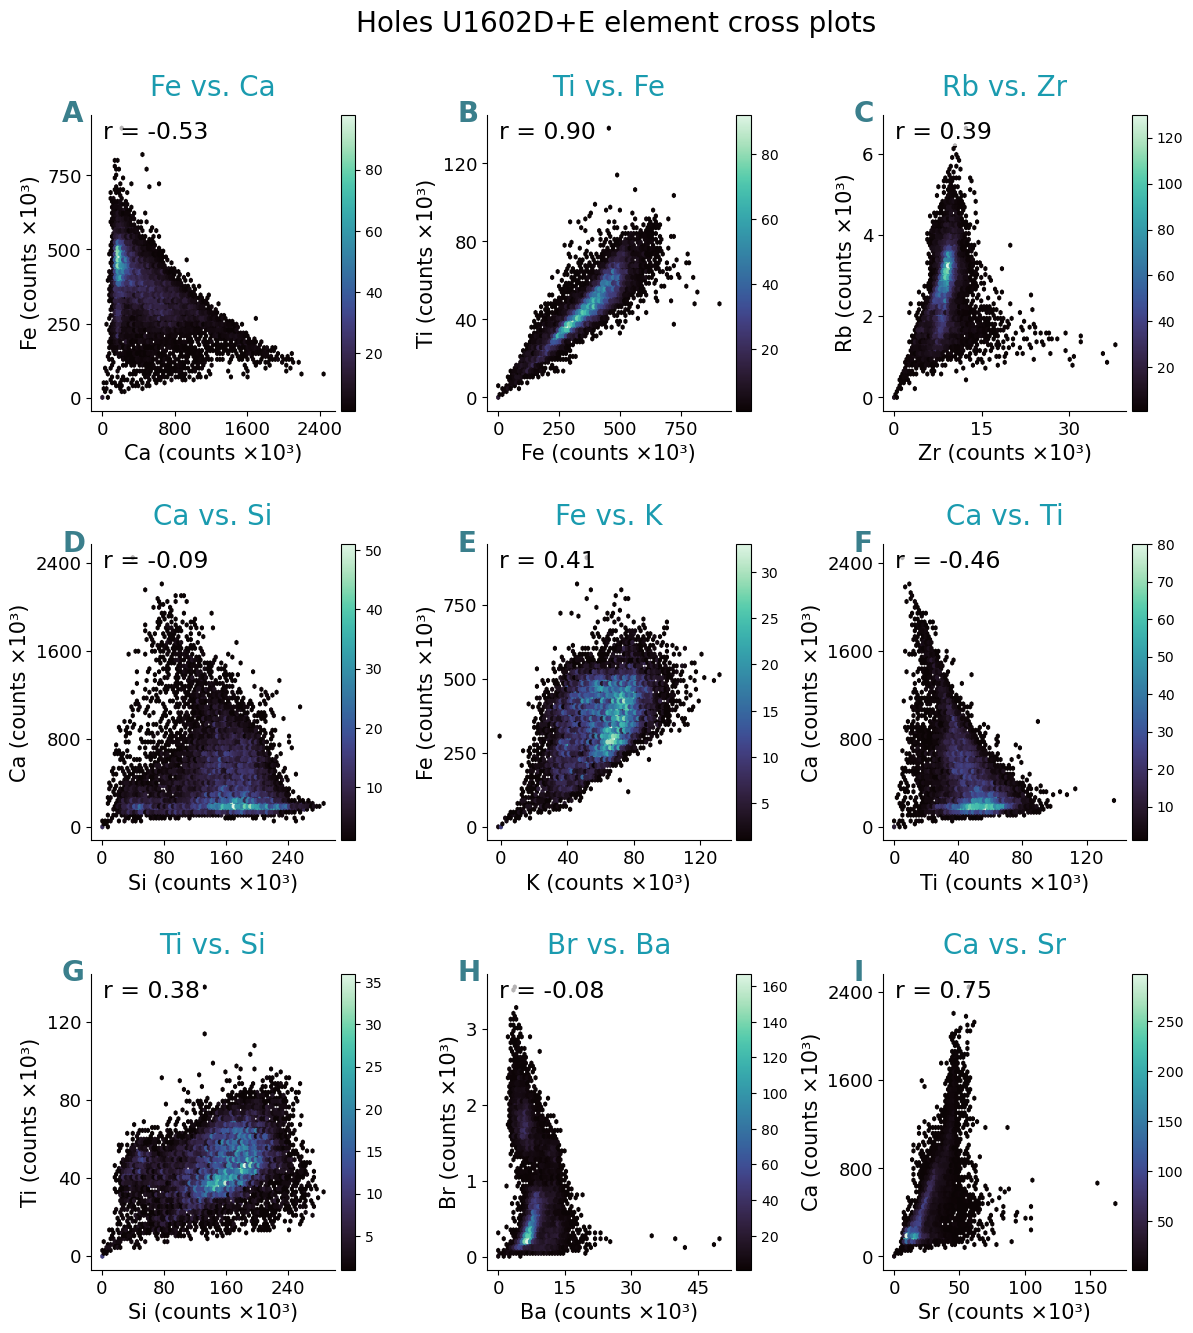

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(14, 15))
axes = axes.flatten()

for ax, (xvar, yvar) in zip(axes, pairs):
    x = get_element(xvar)
    y = get_element(yvar)
    
    df_pair = pd.DataFrame({xvar: x.values[:min(len(x), len(y))], 
                             yvar: y.values[:min(len(x), len(y))]}).dropna()
    
    x_clean = df_pair[xvar]
    y_clean = df_pair[yvar]
    
    hb = ax.hexbin(x_clean, y_clean, gridsize=80, cmap='mako', mincnt=1)
    fig.colorbar(hb, ax=ax, pad=0.02)
    
    # m, b = np.polyfit(x_clean, y_clean, 1)
    # x_line = np.linspace(x_clean.min(), x_clean.max(), 200)
    # ax.plot(x_line, m * x_line + b, color='#c0392b', linewidth=1.5)
    
    r, p = spearmanr(x_clean, y_clean)
    # ax.text(0.95, 0.08, f'r = {r:.2f}', transform=ax.transAxes,
    #         fontsize=15, color='#3a7f8c', ha='right')
    ax.text(0.05, 0.92, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=17, color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))
    
    title_color = '#1A9BAF'
    ax.set_title(f'{yvar} vs. {xvar}', fontsize=20, color=title_color, pad=14)
    
    panel_label = chr(65 + list(axes).index(ax))  # A, B, C...
    ax.text(-0.12, 1.05, panel_label, transform=ax.transAxes,
            fontsize=20, color = '#3a7f8c', fontweight='bold', va='top')
    
    # format axes in thousands to avoid squishing
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    
    ax.set_xlabel(f'{xvar} (counts ×10³)', fontsize=12)
    ax.set_ylabel(f'{yvar} (counts ×10³)', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=11)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))

for ax in axes[:len(pairs)]:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(labelsize=13)

fig.suptitle('Holes U1602D+E element cross plots', fontsize=20, y=0.95)
plt.subplots_adjust(hspace=0.45, wspace=0.35)
plt.show()

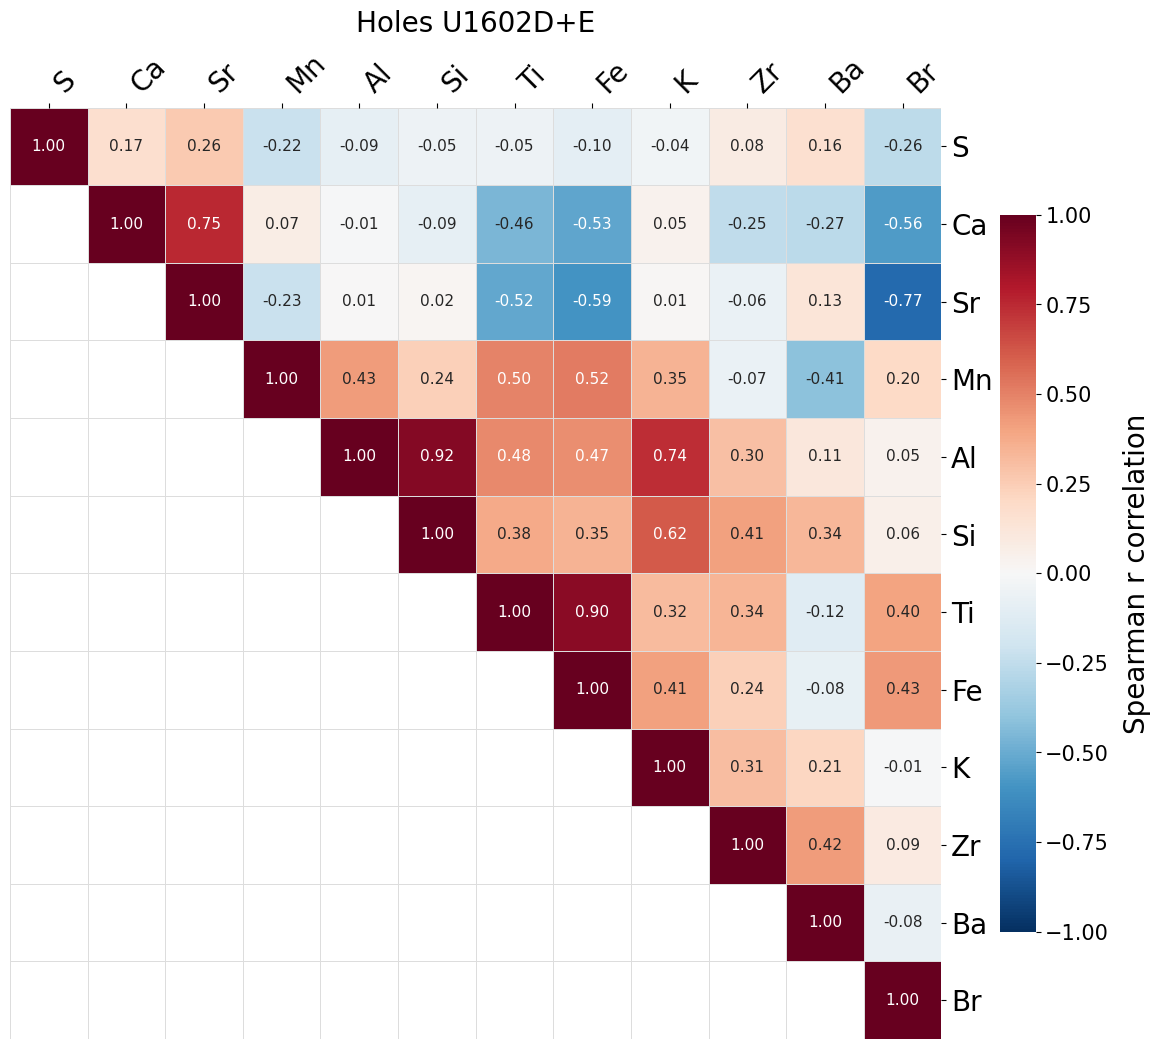

In [26]:
elements_corr_DE = ['S', 'Ca', 'Sr', 'Mn', 'Al', 'Si', 'Ti', 'Fe', 'K', 'Zr', 'Ba', 'Br']


elements_DE['S']  = {'D': (D_10kV, 'S-Ka Area'),  'E': (E_10kV, 'S-Ka Area')}
elements_DE['Mn'] = {'D': (D_10kV, 'Mn-Ka Area'), 'E': (E_10kV, 'Mn-Ka Area')}

df_corr = pd.DataFrame({el: get_element(el).values for el in elements_corr_DE})

corr_matrix = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 11))
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='#dddddd',
            annot_kws={'size': 11},
            cbar_kws={'shrink': 0.7},
            ax=ax)
ax.set_title('Holes U1602D+E', fontsize=20, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left', fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=20)
ax.xaxis.tick_top()
ax.yaxis.tick_right()
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Spearman r correlation', fontsize=20, labelpad=10)
plt.tight_layout()
plt.show()